In [1]:
# Define the default font sizes to make the figures prettier:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### 1) Array Model and Steering Vectors
#### Steering Vector
For a **uniform linear array (ULA)** with $M$ sensors and inter-element spacing $d = \frac{\lambda}{2}$, the **steering (array response) vector** for an impinging plane wave from direction $\theta$ is
$$
\mathbf{s}(\theta) = \begin{bmatrix} 1 & e^{-j\pi \sin \theta} & e^{-j2\pi \sin \theta} & \cdots & e^{-j(M-1)\pi \sin \theta} \end{bmatrix}^T.
$$
This vector characterizes the **spatial phase progression** across array elements for a given direction of arrival.

💡 In Python code (as used in the simulation):
```python
s_theta = np.exp(-1j * np.pi * np.arange(M) * np.sin(theta)
```                 
#### Received Array Snapshot Vector
At discrete time (snapshot) index $n$, the **array snapshot** received across all $M$ sensors is modeled as
$$
\mathbf{u}(n) = A_t \mathbf{s}(\theta_t) e^{j\psi_t(n)} + A_i \mathbf{s}(\theta_i) e^{j\psi_i(n)} + \mathbf{v}(n)
$$

where:

*  $A_t, A_i$  Real or complex amplitudes of the **target** and **interferer** signals (set by SNR/INR) 
* $\mathbf{s}(\theta_t), \mathbf{s}(\theta_i)$ | Steering vectors for the target and interference directions 
* $\psi_t(n), \psi_i(n)$  Instantaneous phases (e.g., random for uncorrelated snapshots) 
* $\mathbf{v}(n)$  Additive white Gaussian noise vector, $\mathbf{v}(n) \sim \mathcal{C}\mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$ 

In the simulation, each $\mathbf{u}(n)$ corresponds to one **snapshot** of the array's output at time index $n$.

💡 In the code this is implemented as:
```python
U[n, :] = A_t * s_t + A_i * s_i + v_n
```
where:
* $\texttt{s\_t}$ and $\texttt{s\_i}$ are the steering vectors for the target and interferer
* $\texttt{v\_n}$ is the complex Gaussian noise at the array elements.
#### Data Matrix Representation
Stacking all snapshots together yields the **array data matrix**
$$
\mathbf{U}_{N,M} = \begin{bmatrix} \mathbf{u}(0) & \mathbf{u}(1) & \cdots & \mathbf{u}(N-1) \end{bmatrix},
$$
which is an $M \times N$ matrix.

Each **column $\mathbf{u}(n)$** represents the spatial samples across sensors at time $n$, and each **row** corresponds to the temporal samples recorded by one sensor.

💡 This matches the $\texttt{U}$ array in the code, where
$\texttt{U.shape = (N\_total, M)}$ and the adaptation uses $\texttt{U\_adapt = U[N\_init:, :]}$.

### 2) From Array Snapshot $\mathbf{u}(n)$ to the GSC Decomposition
After forming the array snapshot $\mathbf{u}(n)$, the **Generalized Sidelobe Canceller (GSC)** structure decomposes the beamformer into two paths:
$$
\mathbf{w}(n) = \mathbf{w}_q - \mathbf{C}_a \mathbf{w}_a(n)
$$

where:

*  $\mathbf{w}_q$  **Quiescent (fixed) weight vector** enforcing the distortionless constraint toward the target 
*  $\mathbf{C}_a$  **Blocking matrix**, removes the desired signal component from the array input 
*  $\mathbf{w}_a(n)$  **Adaptive weight vector**, learns to cancel interference and noise in the sidelobe space 
*  $\mathbf{w}(n)$  **Overall beamformer** combining both components 

## Signal Flow Interpretation (Fig. 2.11)
The decomposition in Haykin's *Fig. 2.11* can be viewed in two equivalent forms:

1.  **Block diagram (a):**
    $\mathbf{u}(n)$ passes through both the quiescent path ($\mathbf{w}_q$) and the adaptive cancellation path ($\mathbf{C}_a, \mathbf{w}_a$).

2.  **Equivalent standard form (b):**
    The adaptive branch becomes a standard **LMS adaptive filter** with
    * input $\mathbf{x}(n) = \mathbf{C}_a^H \mathbf{u}(n)$
    * desired response $d(n) = \mathbf{w}_q^H \mathbf{u}(n)$.

    The LMS update is then applied to $\mathbf{w}_a(n)$.

---
## Constructing the Blocking Matrix $\mathbf{C}_a$
For a ULA with $M$ elements and target steering vector $\mathbf{s}(\theta_t)$, a practical blocking matrix can be formed as:
$$
\mathbf{C}_a^H \mathbf{u}(n) = \text{diag}(\mathbf{u}_1(n)) \mathbf{s}_{2:M}(\theta_t) - \mathbf{u}_{2:M}(n)
$$
This effectively subtracts a phase-corrected replica of the first sensor's signal from the remaining sensors, thus **blocking** the target component while leaving interference and noise.
💡 In the code this is implemented as:
```python
x = (np.diag(U_adapt[:, 0]) @ np.tile(s_t_sub, (N_data, 1))) - U_adapt[:, 1:M]
```

* $\texttt{U\_adapt}[:, 0]$ : First sensor (reference) samples $u_1(n)$ 
* $\texttt{s\_t\_sub}$ : Subvector of the steering vector (elements 2 through $M$) 
* $\texttt{U\_adapt}[:, 1:M]$ : Array data from sensors 2 to $M$ 
* $\mathbf{x}$ : Blocked input vector sequence $\mathbf{x}(n)$ for the LMS filter 

---
## Adaptive Weight Update
The adaptive branch uses a complex LMS algorithm to estimate $\mathbf{w}_a(n)$:
$$
\begin{aligned}
e(n) &= d(n) - \mathbf{w}_a^H(n) \mathbf{x}(n), \\
\mathbf{w}_a(n+1) &= \mathbf{w}_a(n) + \mu \mathbf{x}(n) e^*(n)
\end{aligned}
$$
where:
* $d(n) = g u_1(n)$ is the **desired signal** (from the quiescent path),
* $e(n)$ is the **instantaneous error** (used to adapt $\mathbf{w}_a(n)$).

💡 Implemented in code as:
```python
W_hist, e_hist = lms_complex(x, d, mu)
```
## Reconstructing the Full Beamformer
Once $\mathbf{w}_a(n)$ has converged, the complete MVDR beamformer is reconstructed as:
$$
\mathbf{w}(n) = \mathbf{w}_q - \mathbf{C}_a \mathbf{w}_a(n)
$$
In this implementation:
$$
\mathbf{w}_q = [1, 0, 0, \ldots]^T, \quad \mathbf{C}_a = \begin{bmatrix} \mathbf{0} & \mathbf{I}_{M-1} \end{bmatrix}
$$
so the final combined weights becomes:
$$
\mathbf{w}(n) = \begin{bmatrix} w_{q0} \\ -\mathbf{w}_a(n) \end{bmatrix} \quad \text{where} \quad w_{q0} = g - \mathbf{w}_a^H(n) \mathbf{s}_{2:M}(\theta_t)
$$
💡 In code:
```python
w_a = W_hist[-1, :]
w_q0 = g - np.dot(w_a, np.conj(s_t_sub))
w_full = np.insert(w_a, 0, w_q0)
```
## Spatial Response
The steady-state beam pattern is finally computed as:
$$
P(\sin \theta) = 20 \log_{10} \left( \left| \mathbf{w}^H \mathbf{s}(\theta) \right|^2 + \epsilon \right)
$$
💡 In Python:
```python
S = np.exp(-1j * np.pi * np.outer(np.arange(M), sin_space))
resp_db = 10 * np.log10(np.abs(np.conj(w_full) @ S)**2 + 1e-12)
```

This produces the spatial amplitude response showing:
* A mainlobe steered toward the target $\theta_t$
* A deep null formed in the direction of interference $\theta_i$
* Progressive sharpening as the number of snapshots (adaptation cycles) increases
  
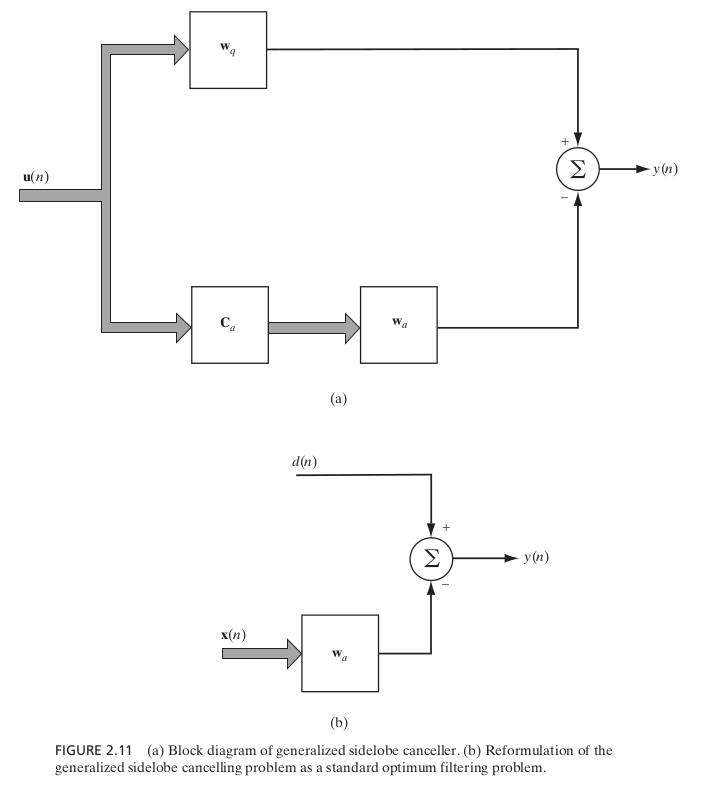

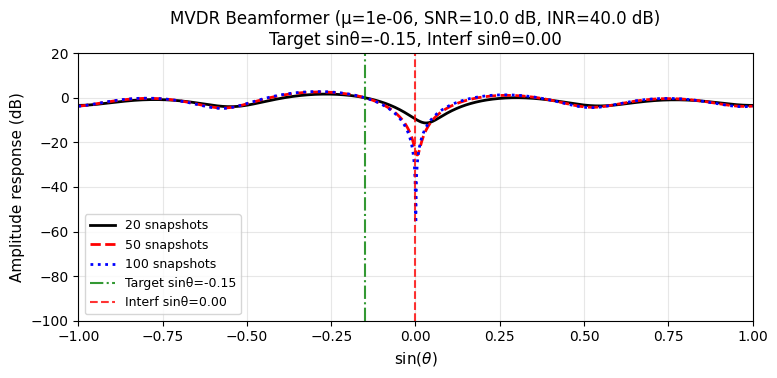

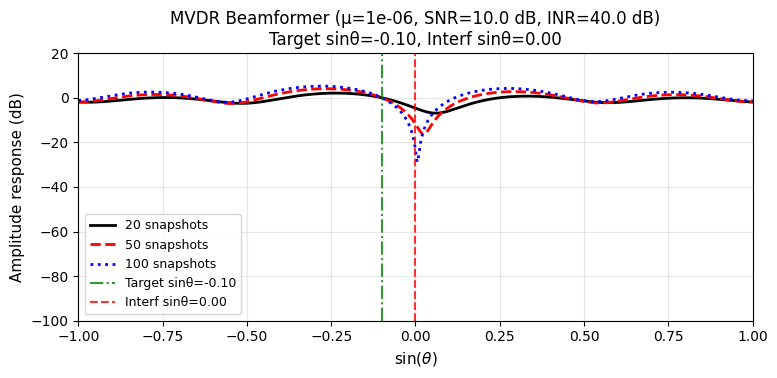

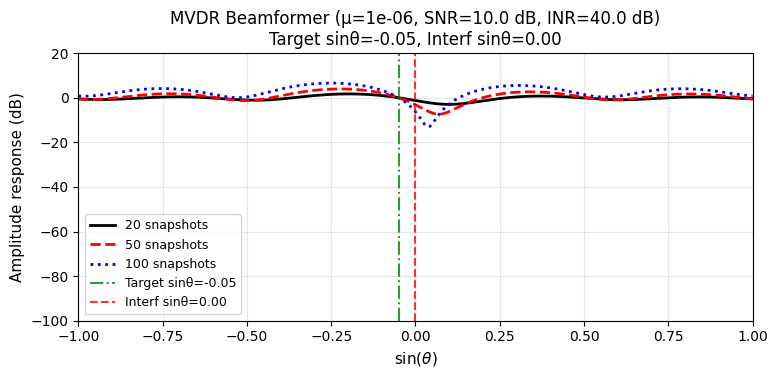

In [3]:
def lms_complex(u, d, mu):
  Ndata, M = u.shape
  W = np.zeros(M, dtype=complex)
  W_history = np.zeros((Ndata, M), dtype=complex)
  e_history = np.zeros(Ndata, dtype=complex)

  for k in range(Ndata):
    u_k = u[k, :]
    y_k = np.vdot(W, u_k)        # W^H u_k
    e_k = d[k] - y_k
    W = W + mu * np.conj(e_k) * u_k
    W_history[k, :] = W
    e_history[k] = e_k

  return W_history, e_history



# One MVDR/LMS adaptation run (GSC form) for a single snapshot count
def run_mvdr_adaptation(
    N_runs,         # number of adaptation snapshots (e.g. 20, 50, 100)
    M,              # number of array elements (M sensors)
    N_resp,         # spatial response resolution (e.g. 1000)
    SNRdB, INRdB,   # target & interference SNR/INR (dB)
    mu,             # LMS step size (e.g. 1e-10)
    var_v,          # noise variance
    sin_theta_t,    # sin(theta_t): target direction
    sin_theta_i,    # sin(theta_i): interference direction
    g=1.0,          # distortionless gain constraint
    N_init=None,    # optional initialization snapshots
    rng=None        # optional random generator
):
    """
    Returns:
      dict with:
        'w_final'  : full MVDR weight vector (M,)
        'sin_space': np.linspace(-1, 1, N_resp)
        'resp_db'  : spatial response in dB
        'final_mse': mean |e(n)|^2 over last few samples
        'w_hist'   : adaptive-branch LMS weight history
        'e_hist'   : LMS error history
    """
    if rng is None:
        rng = np.random.default_rng()
    if N_init is None:
        N_init = M  # consistent with Haykin example

    # Total snapshots (initial + adaptation)
    N_total = N_init + N_runs

    # Convert directions to electrical phase angles (φ = π sinθ)
    phi_t = np.pi * sin_theta_t
    phi_i = np.pi * sin_theta_i

    # Amplitudes from SNR/INR (linear scale)
    A_t, A_i = np.sqrt(var_v) * 10**(np.array([SNRdB, INRdB]) / 20)

    # Steering vector for target direction (used in blocking matrix)
    # s_t = [1, e^{-jφ_t}, ..., e^{-j(M−1)φ_t}]^T
    s_t = np.exp(-1j * np.arange(M) * phi_t)

    # Subvector (1-based indices 1..M−1) used for blocking matrix
    s_t_sub = s_t[1:]

    # Generate array snapshots: 𝑢(n) = s_t + s_i + v(n)
    U = np.zeros((N_total, M), dtype=complex)
    for n in range(N_total):
        # complex Gaussian noise
        v_n = (np.sqrt(var_v/2) * rng.standard_normal(M)
               + 1j * np.sqrt(var_v/2) * rng.standard_normal(M))

        # interference signal with random phase
        psi = 2 * np.pi * rng.random()
        s_i = np.exp(1j * (np.arange(M) * phi_i + psi))

        # total snapshot
        U[n, :] = A_t * s_t + A_i * s_i + v_n

    # Adaptation subset (skip init samples)
    U_adapt = U[N_init:, :]           # (N_runs, M)
    N_data = U_adapt.shape[0]

    # Desired signal: first sensor output scaled by unity gain
    d = g * U_adapt[:, 0]

    # Blocked (interference-only) input for LMS:
    # x(n) = diag(u1) * s_t_sub − u_{2:M}
    x = (np.diag(U_adapt[:, 0]) @ np.tile(s_t_sub, (N_data, 1))) - U_adapt[:, 1:M]

    # Run complex LMS on (x, d)
    w_hist, e_hist = lms_complex(x, d, mu)

    # Reconstruct full MVDR beamformer weights
    w_a = w_hist[-1, :]                      # adaptive branch weights (M−1)
    w_q0 = g - np.dot(w_a, np.conj(s_t_sub))  # quiescent scalar
    w_full = np.insert(w_a, 0, w_q0)         # full beamformer (length M)

    # Compute spatial response
    sin_space = np.linspace(-1.0, 1.0, N_resp)
    # Steering matrix S = [s(θ₁), s(θ₂), …] where s(θ)=exp(−jπk sinθ)
    S = np.exp(-1j * np.pi * np.outer(np.arange(M), sin_space))
    P_lin = np.abs(np.conj(w_full) @ S)**2
    resp_db = 10 * np.log10(P_lin + 1e-12)

    # Steady-state MSE estimate
    tail = min(10, len(e_hist))
    final_mse = float(np.mean(np.abs(e_hist[-tail:])**2))

    return {
        'w_final': w_full,
        'sin_space': sin_space,
        'resp_db': resp_db,
        'final_mse': final_mse,
        'w_hist': w_hist,
        'e_hist': e_hist
    }

# -------------------------------------------------------------
# Problem setup for MVDR / LMS (GSC) beamforming experiment
# -------------------------------------------------------------
mu = 1e-6
g = 1.0
M = 5                         # number of array elements
N_init = M
N_runs_list = [20, 50, 100]   # number of adaptation snapshots
var_v = 1.0
SNRdB = 10.0
INRdB = 40.0
N_resp = 1000              # spatial response resolution

# target directions (approaching the interferer at sinθ=0)
sin_theta_targets = [-0.15, -0.10, -0.05]
sin_theta_i = 0.0          # interference direction

rng = np.random.default_rng(1234)

# -------------------------------------------------------------
# Simulation loop over target directions
# -------------------------------------------------------------
for sin_theta_t in sin_theta_targets:
    plt.figure(figsize=(8, 4))

    for N_runs, color, ls in zip(N_runs_list, ['k', 'r', 'b'], ['-', '--', ':']):
        out = run_mvdr_adaptation(
            N_runs=N_runs,
            M=M,
            N_resp=N_resp,
            SNRdB=SNRdB,
            INRdB=INRdB,
            mu=mu,
            var_v=var_v,
            sin_theta_t=sin_theta_t,
            sin_theta_i=sin_theta_i,
            g=g,
            N_init=N_init,
            rng=rng
        )

        # plot spatial response
        plt.plot(out['sin_space'], out['resp_db'],
                 color=color, linestyle=ls, linewidth=2,
                 label=f'{N_runs} snapshots')

    # mark target and interference directions
    plt.axvline(x=sin_theta_t, color='green', linestyle='-.', linewidth=1.5, alpha=0.8,
                label=f'Target sinθ={sin_theta_t:.2f}')
    plt.axvline(x=sin_theta_i, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                label=f'Interf sinθ={sin_theta_i:.2f}')

    # axis and labels
    plt.axis([-1, 1, -100, 20])
    plt.xlabel(r'$\sin(\theta)$', fontsize=11)
    plt.ylabel('Amplitude response (dB)', fontsize=11)
    plt.title(
        f'MVDR Beamformer (μ={mu:.0e}, SNR={SNRdB} dB, INR={INRdB} dB)\n'
        f'Target sinθ={sin_theta_t:.2f}, Interf sinθ={sin_theta_i:.2f}',
        fontsize=12
    )
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()


"why" behind the blocking matrix form
$$\mathbf{x}(n) = \text{diag}(\mathbf{u}_1(n)) \mathbf{s}_{2:M}(\theta_t) - \mathbf{u}_{2:M}(n)$$
is fundamental to understanding the **Generalized Sidelobe Canceller (GSC)**.

Let's go step by step 👇

---

* **1. Role of the Blocking Matrix in GSC**

The **blocking matrix $\mathbf{C}_a$** is the key component that creates a **reference signal** for the adaptive filter.

Its job is to:
* **Remove the desired signal component** (the target direction),
* **Preserve interference and noise components**.

In other words:
$$
\mathbf{C}_a^H \mathbf{s}(\theta_t) = \mathbf{0}.
$$

That is, $\mathbf{C}_a$ is designed so that when the desired signal's steering vector is applied, the output is zero --- meaning the **target signal is completely blocked**.

* **2. Starting from the Array Output**

Each array snapshot is:
$$
\mathbf{u}(n) = A_t \mathbf{s}(\theta_t) e^{j\psi_t(n)} + A_i \mathbf{s}(\theta_i) e^{j\psi_i(n)} + \mathbf{v}(n)
$$
If you feed this directly to an adaptive filter, the LMS algorithm might **distort the target signal** --- because it can't distinguish target vs. interference.

So, we first "**block**" the target signal from the adaptive path.

---

* **3. Intuitive Construction**

For a uniform linear array (ULA), the **steering vector for the target** is:
$$
\mathbf{s}(\theta_t) = \begin{bmatrix}
1 \\
e^{-j\pi \sin \theta_t} \\
e^{-j2\pi \sin \theta_t} \\
\vdots \\
e^{-j(M-1)\pi \sin \theta_t}
\end{bmatrix}.
$$

If the first element's output is $u_1(n)$, we can predict what the desired signal **should look like** at sensor $m$ (for the target direction) as:
$$
\hat{u}_m(n) = u_1(n) e^{-j\pi (m-1) \sin \theta_t}.
$$
That's because the phase difference between sensors is exactly $e^{-j\pi (m-1) \sin \theta_t}$.

* **4. Constructing the Blocked Signal**

So, to **remove the target** from each of the remaining sensors (2 to $M$): we subtract the predicted target component from the actual received data:
$$
x_m(n) = u_1(n) e^{-j\pi (m-1) \sin \theta_t} - u_m(n), \quad m = 2, \ldots, M.
$$

This gives the **blocked signals**:
* If the signal truly arrives from $\theta_t$, then $x_m(n) \approx 0$.
* But interference or noise that does **not** match the steering vector remains.

Stacking all $M-1$ of these into a vector:
$$
\mathbf{x}(n) = \text{diag}(\mathbf{u}_1(n)) \mathbf{s}_{2:M}(\theta_t) - \mathbf{u}_{2:M}(n)
$$
This is the form used in both the MATLAB and Python implementations.

---

* **5. Why It Works**

Let's substitute $\mathbf{u}(n) = A_t \mathbf{s}(\theta_t) e^{j\psi_t(n)} + \text{other terms}$:
$$
\begin{aligned}
\mathbf{x}(n) &= \text{diag}(A_t e^{j\psi_t(n)} s_1(\theta_t)) \mathbf{s}_{2:M}(\theta_t) - A_t e^{j\psi_t(n)} \mathbf{s}_{2:M}(\theta_t) \\
&= A_t e^{j\psi_t(n)} (\mathbf{s}_1(\theta_t) \mathbf{s}_{2:M}(\theta_t) - \mathbf{s}_{2:M}(\theta_t)) = \mathbf{0}.
\end{aligned}
$$
Thus, the **desired signal is completely removed (blocked)**.

But the interference component $A_i \mathbf{s}(\theta_i) e^{j\psi_i(n)}$ will not cancel perfectly because $\mathbf{s}(\theta_i) \ne \mathbf{s}(\theta_t)$.
Hence, **interference and noise remain** --- exactly what we need for the adaptive canceller to learn from.

* **6. Implementation in Code**

In your Python simulation:
```python
u = (np.diag(U_adapt[:, 0]) @ np.tile(s_t_sub, (N_data, 1))) - U_adapt[:, 1:M]
```

* $\texttt{U\_adapt}[:, 0] \rightarrow u_1(n)$, first sensor (reference)
* $\texttt{s\_t\_sub} \rightarrow \mathbf{s}_{2:M}(\theta_t)$, steering vector (excluding first element)
* $\texttt{U\_adapt}[:, 1:M] \rightarrow \mathbf{u}_{2:M}(n)$, remaining sensor outputs
* Result $\texttt{u} \rightarrow$ the blocked input matrix (each row $= \mathbf{x}^T(n)$)

---
* **7. Geometric Interpretation**

* The blocking matrix projects the received vector $\mathbf{u}(n)$ onto the **subspace orthogonal to the desired steering vector**.
* This removes the target component, leaving only interference + noise.
* The adaptive filter then learns the optimal combination to minimize leakage of interference into the main path.

---
✅ **Summary**

| Purpose | Mathematical Idea | Implementation |
| :--- | :--- | :--- |
| Remove target signal from adaptive input | $\mathbf{C}_a^H \mathbf{s}(\theta_t) = \mathbf{0}$ | $\texttt{diag(U[:, 0]) @ s\_t\_sub - U[:, 1:M]}$ |
| Leave interference \& noise | $\mathbf{s}(\theta_i) \ne \mathbf{s}(\theta_t)$ | Survives subtraction |
| Enable LMS adaptation | $\mathbf{x}(n), d(n)$ pair | $\texttt{lms\_complex(x, d, mu)}$ |
---
* **8. Math Interpretation Practical Blocking Matrix --- "First-Sensor Prediction" Derivation**
We want a **blocked input $\mathbf{x}(n)$** that contains no desired signal but keeps interference + noise:
$$
\mathbf{x}(n) = \mathbf{C}_a^H \mathbf{u}(n), \quad \mathbf{C}_a^H \mathbf{s}(\theta_t) = \mathbf{0}
$$
**Idea:** predict each downstream sensor from the first sensor using the known steering law

For a ULA, the desired steering vector is
$$
\mathbf{s}(\theta_t) = \begin{bmatrix} 1 & e^{-j\pi \sin \theta_t} & e^{-j2\pi \sin \theta_t} & \cdots & e^{-j(M-1)\pi \sin \theta_t} \end{bmatrix}^T.
$$
If the first sensor output is $u_1(n)$, then the **desired component** at sensor $m$ (for the same plane wave) is predicted by
$$
\tilde{u}_m^{(\text{des})}(n) = u_1(n) \underbrace{e^{-j\pi (m-1) \sin \theta_t}}_{\text{relative phase from steering}}, \quad m = 2, \ldots, M.
$$
We then **subtract this prediction** from the actual measurement to remove the desired component:
$$
x_m(n) = \underbrace{u_1(n) e^{-j\pi (m-1) \sin \theta_t}}_{\text{predicted desired at sensor } m} - \underbrace{u_m(n)}_{\text{actual measurement}}, \quad m = 2, \ldots, M.
$$
Stacking $m = 2 \ldots M$ gives the blocked vector
$$
\mathbf{x}(n) = \mathbf{diag}(u_1(n)) \mathbf{s}_{2:M}(\theta_t) - \mathbf{u}_{2:M}(n) \quad \iff \quad \mathbf{x}(n) = \mathbf{C}_a^H \mathbf{u}(n).
$$

## Why this blocks the desired signal
Assume the desired field is
$$
\mathbf{u}^{(\text{des})}(n) = A_t e^{j\psi_t(n)} \mathbf{s}(\theta_t).
$$
Then $u_1^{(\text{des})}(n) = A_t e^{j\psi_t(n)}$, and for $m \ge 2$:
$$
\tilde{u}_m^{(\text{des})}(n) = u_1^{(\text{des})}(n) e^{-j\pi (m-1) \sin \theta_t} = A_t e^{j\psi_t(n)} e^{-j\pi (m-1) \sin \theta_t} = u_m^{(\text{des})}(n).
$$
Hence
$$
x_m^{(\text{des})}(n) = \tilde{u}_m^{(\text{des})}(n) - u_m^{(\text{des})}(n) = 0 \quad \implies \mathbf{x}^{(\text{des})}(n) = \mathbf{0}.
$$
So the desired signal is **exactly cancelled** in the blocked path.

Interference with $\theta_i \ne \theta_t$ will not match the phase law above, so it **does not cancel**, and neither does noise. This gives the LMS branch a clean reference of **interference + noise** to learn from.

22. Repeat the computer experiment on $\mathbf{MVDR}$ beamforming described in Section 6.9 for a target-signal-to-noise ratio of $10\text{ dB}$, interference-to-noise ratio of $40\text{ dB}$, and step-size parameter $\mu = 10^{-10}$. As before, the angle-of-arrival for the interference is
$$
\phi_{\text{interf}} = \sin^{-1}(0).
$$
This time, however, we investigate what happens to the spatial response of the beamformer as the target moves closer to the source of interference. Specifically, plot the spatial response for an increasing number of adaptation cycles for each of the following angles-of-arrival for the target:
    *  $\phi_{\text{target}} = \sin^{-1}(-0.15)$
    *  $\phi_{\text{target}} = \sin^{-1}(-0.10)$
    *  $\phi_{\text{target}} = \sin^{-1}(-0.05)$
      
Comment on your results.

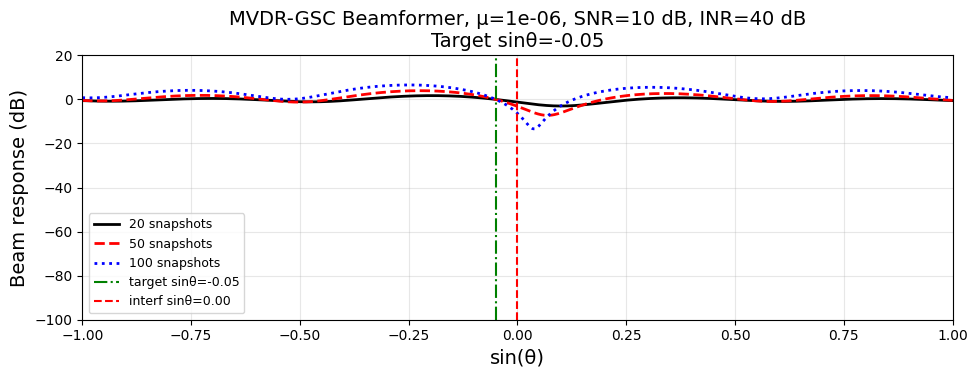

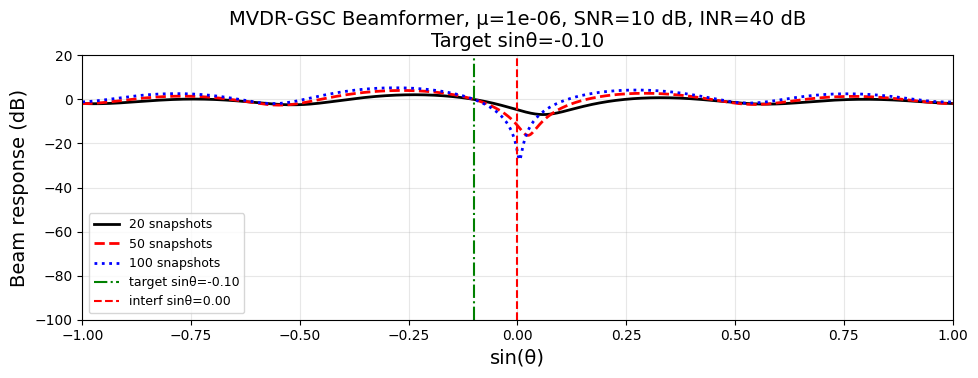

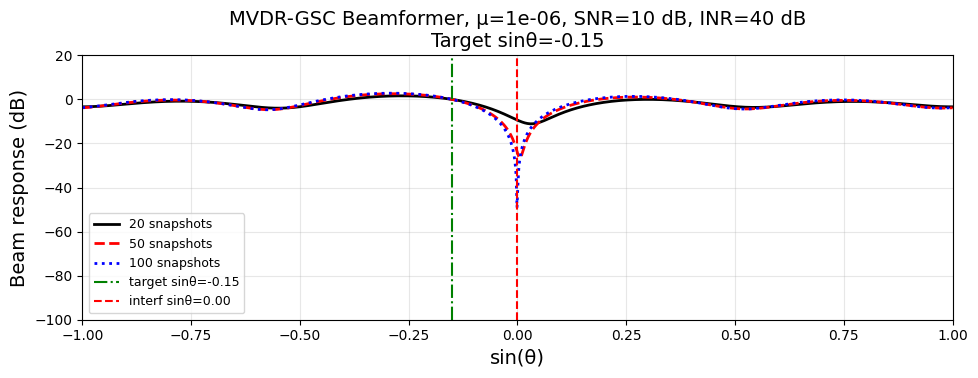

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Complex LMS used in the MVDR–GSC adaptive blocking stage
# ============================================================
def lms_complex(u, d, mu):
    Ndata, M = u.shape
    W = np.zeros(M, dtype=complex)                 # adaptive weights
    W_history = np.zeros((Ndata, M), dtype=complex)
    e_history = np.zeros(Ndata, dtype=complex)

    for k in range(Ndata):
        u_k = u[k, :]                              # regression vector
        y_k = np.vdot(W, u_k)                      # W^H u_k
        e_k = d[k] - y_k                           # error
        W = W + mu * np.conj(e_k) * u_k            # LMS update

        W_history[k, :] = W
        e_history[k] = e_k

    return W_history, e_history



# ============================================================
# ONE MVDR–GSC ADAPTATION RUN
# ============================================================
def run_mvdr_adaptation_6_22(
    N_runs,      # number of adaptation samples (20, 50, 100)
    M,           # number of array sensors
    N_resp,      # spatial response grid resolution
    SNRdB, INRdB,
    mu, var_v,
    sin_theta_t, sin_theta_i,
    g=1.0,
    N_init=None,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    if N_init is None:
        N_init = M          # same as MATLAB

    N_total = N_init + N_runs

    # ---------------------------------------------------------
    # Convert direction to electrical angles φ = π sinθ
    # ---------------------------------------------------------
    phi_t = np.pi * sin_theta_t
    phi_i = np.pi * sin_theta_i

    # Amplitudes of target and interference
    A_t, A_i = np.sqrt(var_v) * 10**(np.array([SNRdB, INRdB])/20)

    # Target steering vector s_t
    s_t = np.exp(-1j * np.arange(M) * phi_t)
    sig_t = A_t * s_t       # ignoring ψ_t(n) since does not affect MVDR

    # Snapshot array X[n, m]
    X = np.zeros((N_total, M), dtype=complex)

    for n in range(N_total):
        # Noise
        v_n = (np.sqrt(var_v/2) * rng.standard_normal(M)
               + 1j*np.sqrt(var_v/2) * rng.standard_normal(M))

        # Interference with random phase
        psi = 2*np.pi*rng.random()
        sig_i = A_i * np.exp(1j*(np.arange(M)*phi_i + psi))

        # Full snapshot
        X[n, :] = sig_t + sig_i + v_n

    # ============================================================
    # Prepare LMS input-output pairs
    # Desired signal d(n) = first sensor output
    # ============================================================
    X_adapt = X[N_init:, :]           # adaptive data only
    d = g * X_adapt[:, 0]             # desired signal


    # ---------------------------------------------------------
    # Blocking-matrix regression signal u(n)
    # u(n) = x1(n)*e^T  –  X[n, 1:M]
    # ---------------------------------------------------------
    e_vec = np.exp(-1j * np.arange(1, M) * phi_t)   # length M-1
    E = np.tile(e_vec, (N_runs, 1))                 # shape (N_runs, M-1)

    x1 = X_adapt[:, 0].reshape(-1, 1)
    term1 = x1 * E
    term2 = X_adapt[:, 1:M]

    u = term1 - term2                       # shape (N_runs, M-1)

    # ============================================================
    # Run complex LMS
    # ============================================================
    W_hist, e_hist = lms_complex(u, d, mu)

    # ============================================================
    # Convert GSC branch weights to FULL MVDR weights
    # ============================================================
    W_a = W_hist[-1, :]                     # final adaptive weights (length M-1)
    W0 = g - np.dot(W_a, np.conj(e_vec))    # scalar quiescent component

    W_full = np.insert(W_a, 0, W0)          # total MVDR weight vector


    # ============================================================
    # Compute spatial response
    # ============================================================
    st = np.linspace(-1, 1, N_resp)
    A = np.exp(-1j * np.pi * np.outer(np.arange(M), st))   # M×N_resp steering matrix

    resp = np.abs(np.conj(W_full) @ A)**2
    resp_db = 10 * np.log10(resp + 1e-12)                  # stable dB conversion

    return {
        'W': W_full,
        'st': st,
        'resp_db': resp_db,
        'e_hist': e_hist,
        'W_hist': W_hist
    }



# ============================================================
# RUN FULL EXPERIMENT + PLOTTING
# ============================================================
mu = 1e-6
g = 1
M = 5
N_init = M
N_snaps = [20, 50, 100]
var_v = 1.0

SNRdB = 10
INRdB = 40

sin_theta_ts = np.array([-0.05, -0.10, -0.15])
sin_theta_i  = 0.0

N_resp = 1000

rng = np.random.default_rng(999)

for sin_theta_t in sin_theta_ts:

    plt.figure(figsize=(10, 4))

    for N_runs, c, ls in zip(N_snaps, ['k', 'r', 'b'], ['-', '--', ':']):
        out = run_mvdr_adaptation_6_22(
            N_runs=N_runs,
            M=M,
            N_resp=N_resp,
            SNRdB=SNRdB,
            INRdB=INRdB,
            mu=mu,
            var_v=var_v,
            sin_theta_t=sin_theta_t,
            sin_theta_i=sin_theta_i,
            g=g,
            N_init=N_init,
            rng=rng
        )

        plt.plot(out['st'], out['resp_db'], ls, color=c, linewidth=2,
                 label=f"{N_runs} snapshots")


    # Target & interference markers
    plt.axvline(sin_theta_t, color="green", linestyle="-.", linewidth=1.5,
                label=f"target sinθ={sin_theta_t:.2f}")
    plt.axvline(sin_theta_i, color="red", linestyle="--", linewidth=1.5,
                label=f"interf sinθ={sin_theta_i:.2f}")

    plt.xlabel("sin(θ)")
    plt.ylabel("Beam response (dB)")
    plt.title(f"MVDR-GSC Beamformer, μ={mu}, SNR={SNRdB} dB, INR={INRdB} dB\n"
              f"Target sinθ={sin_theta_t:.2f}")
    plt.axis([-1, 1, -100, 20])
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower left", fontsize=9)
    plt.tight_layout()
    plt.show()
